In [24]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

In [25]:
df = pd.read_csv('timeseries.csv', parse_dates=['Date'], index_col='Date')
df.index.freq = pd.infer_freq(df.index)
df.head()

,Value
Date,
2023-01-01,100.0
2023-01-02,102.5
2023-01-03,101.2
2023-01-04,103.8
2023-01-05,105.0


## ADF Test to check for stationarity

In [26]:
result = adfuller(df['Value'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] > 0.05:
    print("The series is non-stationary. Differencing is needed.")
else:
    print("The series is stationary.")

ADF Statistic: -0.033354709409650324
p-value: 0.9556852039955246
The series is non-stationary. Differencing is needed.


In [27]:
# First-order differencing
df['Differenced'] = df['Value'].diff()

df.dropna(inplace=True)
print(df[['Value', 'Differenced']].head())

            Value  Differenced
Date                          
2023-01-02  102.5          2.5
2023-01-03  101.2         -1.3
2023-01-04  103.8          2.6
2023-01-05  105.0          1.2
2023-01-06  104.2         -0.8


## Fit the ARIMA model

In [28]:
model = ARIMA(df['Value'], order=(1, 1, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=10)

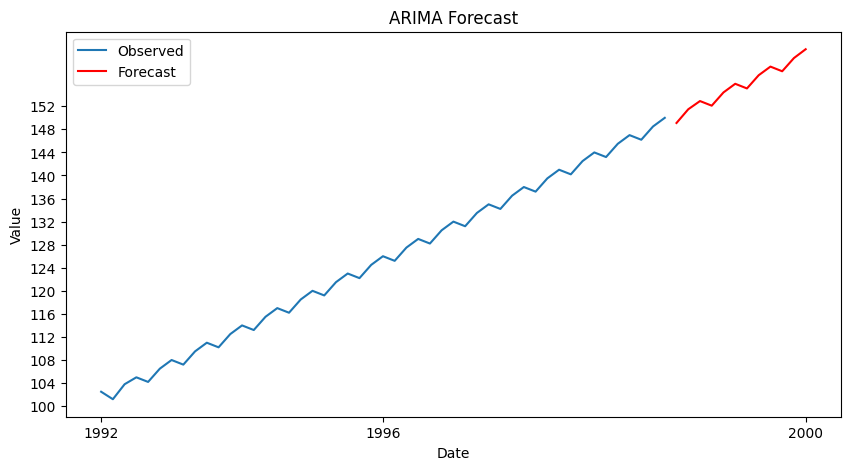

In [41]:
plt.figure(figsize=(10, 5))
x_obs = np.arange(len(df))
plt.plot(x_obs, df['Value'], label='Observed')

forecast_len = len(forecast)
x_forecast = np.arange(len(df), len(df) + forecast_len)
plt.plot(x_forecast, forecast, label='Forecast', color='red')

ax = plt.gca()
ax.set_xticks([0, len(df) // 2, len(df) + forecast_len - 1])
ax.set_xticklabels(['1992', '1996', '2000'])

y_min, y_max = df['Value'].min(), df['Value'].max()
ax.set_yticks(list(range(int(y_min // 4 * 4), int(y_max + 4), 4)))

plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Exponential Smoothing Time Series (ETS)

In [42]:
ets_model = ExponentialSmoothing(df['Value'], seasonal='add', trend='add', seasonal_periods=12)
ets_fit = ets_model.fit()

In [43]:
forecast = ets_fit.forecast(steps=12)

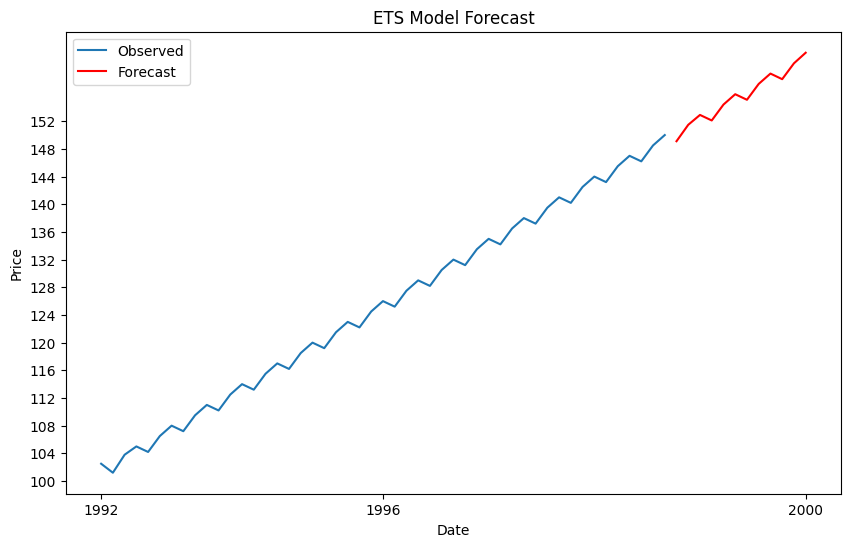

In [46]:
plt.figure(figsize=(10, 6))

# Use numeric x-axis so we can set custom tick labels
x_obs = np.arange(len(df))
plt.plot(x_obs, df['Value'], label='Observed')

forecast_len = len(forecast)
x_forecast = np.arange(len(df), len(df) + forecast_len)
plt.plot(x_forecast, forecast, label='Forecast', color='red')

ax = plt.gca()
ax.set_xticks([0, len(df) // 2, len(df) + forecast_len - 1])
ax.set_xticklabels(['1992', '1996', '2000'])

y_min, y_max = df['Value'].min(), df['Value'].max()
ax.set_yticks(list(range(int(y_min // 4 * 4), int(y_max + 4), 4)))

plt.title('ETS Model Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## LSTM

In [67]:
data = df['Value'].values
data = data.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.02663934]
 [0.        ]
 [0.05327869]
 [0.07786885]
 [0.06147541]]


In [75]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, 0])
        y.append(data[i+time_steps, 0])
    return np.array(X), np.array(y)

min_samples = 2
time_steps = min(60, max(1, len(scaled_data) // 2))

if len(scaled_data) - time_steps < min_samples:
    time_steps = max(1, len(scaled_data) - min_samples)

X, y = create_sequences(scaled_data, time_steps)

if X.size == 0:
    raise ValueError(
        f"Not enough data to create sequences (got {len(scaled_data)} points, time_steps={time_steps})."
    )

X = X.reshape(X.shape[0], X.shape[1], 1)

In [84]:
train_size = max(1, int(len(X) * 0.8))
if train_size >= len(X):
    train_size = len(X) - 1
train_size = max(1, train_size)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train.shape={X_train.shape}, X_test.shape={X_test.shape}")
print(f"y_train.shape={y_train.shape}, y_test.shape={y_test.shape}")

X_train.shape=(20, 24, 1), X_test.shape=(5, 24, 1)
y_train.shape=(20,), y_test.shape=(5,)


In [77]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

In [78]:
model = Sequential()

model.add(Input(shape=(time_steps, 1)))  
model.add(LSTM(50, return_sequences=False))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
batch_size = 1
epochs = 100

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=0,
)

from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f"Test RMSE: {rmse:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Test RMSE: 1.089


# Make predictions on the test data


In [87]:
y_pred = model.predict(X_test)

y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

print(y_pred_rescaled[:5])
print(y_test_rescaled[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[144.98044]
 [145.82027]
 [146.68024]
 [147.47466]
 [148.27351]]
[[145.5]
 [147. ]
 [146.2]
 [148.5]
 [150. ]]


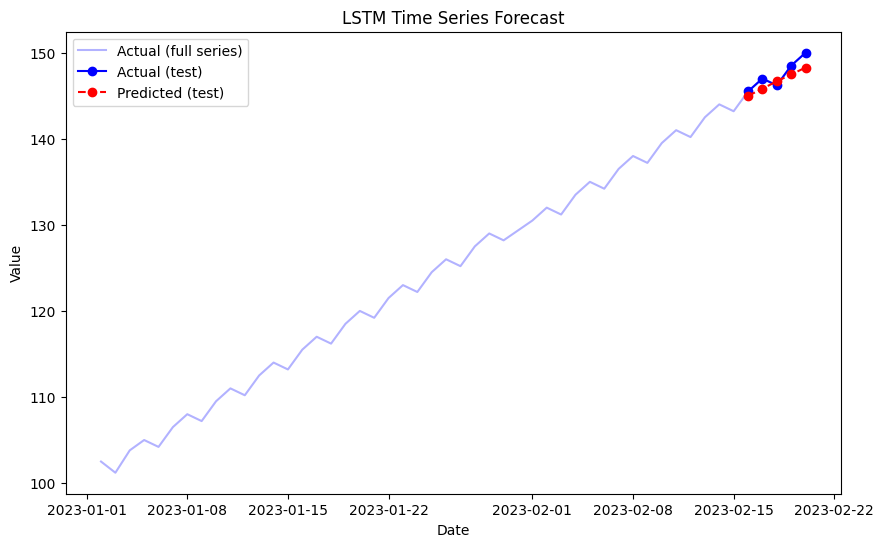

In [89]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Value'], label='Actual (full series)', color='blue', alpha=0.3)

pred_start_idx = time_steps + train_size
pred_end_idx = pred_start_idx + len(y_pred_rescaled)
pred_index = df.index[pred_start_idx:pred_end_idx]

# Plot actual vs predicted on the test interval for direct comparison
plt.plot(pred_index, y_test_rescaled, label='Actual (test)', color='blue', marker='o')
plt.plot(pred_index, y_pred_rescaled, label='Predicted (test)', color='red', linestyle='--', marker='o')

plt.title('LSTM Time Series Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()